In [1]:
import pandas as pd
from joblib import load
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\function_dataset_v2.csv')

In [3]:
X = df.drop(columns=['sample_id', 'label', 'noise_sigma'])
y = df['label']
sample_id = df['sample_id']     # sample_id 不拿去訓練模型

In [4]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [5]:
# 載入最佳模型
best_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\best_model_v2.joblib')

In [6]:
y_pred = best_model.predict(X_test)

## 錯誤分析

In [7]:
# 建立測試資料表
test_all_df = pd.DataFrame({'sample_id': id_test.values,
                            'label': y_test.values,
                            'predicted_label': y_pred})

In [8]:
test_all_df['error'] = (test_all_df['label'] != test_all_df['predicted_label'])

In [9]:
print("----預測錯誤分析----")
print(f"測試樣本數: {len(test_all_df)}")
print(f"預測錯誤數量: {test_all_df['error'].sum()}")
print(f"整體錯誤率: {test_all_df['error'].mean():.2%}\n")

----預測錯誤分析----
測試樣本數: 800
預測錯誤數量: 206
整體錯誤率: 25.75%



In [10]:
metadata = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\function_metadata_v2.csv')

In [11]:
metadata = metadata[['sample_id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [12]:
# 加入 metadata
test_metadata = metadata.copy()

In [13]:
# 透過樣本編號對應到 metadata
error_metadata = test_all_df.merge(metadata, on='sample_id', how='left', validate='one_to_one')

In [14]:
# 找出 Sine/Cosine 之間的錯誤點
test_df = test_all_df[test_all_df['label'].isin(['sine', 'cosine'])].copy()
test_df = test_df.merge(test_metadata, on='sample_id', how='left', validate='one_to_one')

In [15]:
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
sine_to_cosine = ((y_test == 'sine') & (y_pred == 'cosine'))
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') &
                                      (error_metadata['predicted_label']=='cosine')]
print("錯誤樣本:")
print(sine_cosine_metadata[['sample_id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Sine被誤判成Cosine: 8
錯誤樣本:
 sample_id label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
      2691  sine          cosine  0.492075 3.297131  0.715995  0.555581     0.016522
      2793  sine          cosine  0.759309 2.794285  0.783329 -1.690953     0.036427
      2936  sine          cosine  0.388312 3.010551 -0.007066  0.632272     0.020254
      2563  sine          cosine -1.119398 2.030401 -0.731081 -0.813890     0.027749
      2820  sine          cosine  1.207843 3.444438  0.758748 -1.779178     0.042848
      2956  sine          cosine  1.054982 3.920876  0.765863  0.061847     0.066177
      2611  sine          cosine  0.716814 1.769628  0.558837 -0.881077     0.037892
      2807  sine          cosine  0.300000 2.937534 -0.696867  0.678635     0.014315


In [16]:
print(f"\nCosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")
cosine_to_sine = ((y_test == 'cosine') & (y_pred == 'sine'))
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') &
                                      (error_metadata['predicted_label']=='sine')]
print("錯誤樣本:")
print(cosine_sine_metadata[['sample_id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))


Cosine被誤判成Sine: 14
錯誤樣本:
 sample_id  label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
      3156 cosine            sine  0.300000 3.189075 -0.622873  0.122324     0.004325
      3216 cosine            sine  0.745749 3.734913  0.659078 -0.902154     0.049644
      3473 cosine            sine  1.039649 1.663480  0.718244  0.012576     0.030061
      3484 cosine            sine -0.982713 3.964956 -0.008225  0.859872     0.034586
      3016 cosine            sine  0.300000 2.123557 -0.655078 -1.368749     0.016019
      3040 cosine            sine -0.300000 2.643993 -0.603793  0.660737     0.018401
      3420 cosine            sine -0.300000 1.280431 -0.776238 -1.853101     0.013208
      3268 cosine            sine  1.213807 3.952455  0.772011  0.368921     0.034823
      3145 cosine            sine -1.048898 2.790173 -0.655290  0.675418     0.040810
      3352 cosine            sine  0.900213 1.046753 -0.782759  0.731320     0.013355
      3407 cosine           

In [17]:
# 其他錯誤
others = test_all_df['error'].sum() - \
    ((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum() - \
    ((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()
print(f"\n其他錯誤: {others}")
print("Sine / Cosine 的其他錯誤樣本:")
other_errors = test_df[(test_df['error']) &
    ~(((test_df['label'] == 'sine') & (test_df['predicted_label'] == 'cosine')) |
      ((test_df['label'] == 'cosine') & (test_df['predicted_label'] == 'sine')))]
print(other_errors[['sample_id', 'label', 'predicted_label',
                    'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))


其他錯誤: 184
Sine / Cosine 的其他錯誤樣本:
 sample_id  label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
      3286 cosine     logarithmic -0.592639 1.066771 -0.667079 -1.970628     0.013267
      2899   sine      reciprocal -0.300000 1.337229  0.670228  1.602876     0.008977
      3248 cosine       quadratic -1.990216 1.173302 -0.573628 -1.010884     0.123687
      2963   sine     logarithmic -0.300000 1.192732 -0.315363 -0.511979     0.021847
      2765   sine      reciprocal  0.300000 1.142840 -0.482295 -1.775666     0.007607
      3413 cosine           cubic  1.593268 1.001193 -0.759386 -0.490871     0.054218


## 以參數做錯誤分析

In [18]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [19]:
test_para_df = test_all_df.merge(metadata, on='sample_id', how='left', validate='one_to_one')

In [20]:
parameters = ['param_1', 'param_2', 'param_3', 'param_4']
parameter_summary = []
for parameter in parameters:
    correct_data = test_para_df[test_all_df['error'] == False][parameter]
    error_data = test_para_df[test_all_df['error'] == True][parameter]
    parameter_summary.append({'Parameter': parameter,
                              'Correct Mean': correct_data.mean(),
                              'Correct Median': correct_data.median(),
                              'Error Mean': error_data.mean(),
                              'Error Median': error_data.median(),
                              'Mean Difference': (error_data.mean() - correct_data.mean())})
para_sum_df = pd.DataFrame(parameter_summary)

In [21]:
print("正確樣本 vs 錯誤樣本參數比較")
print(para_sum_df.to_string(index=False, formatters={'Correct Mean': '{:.3f}'.format,
                                                     'Correct Median': '{:.3f}'.format,
                                                     'Error Mean': '{:.3f}'.format,
                                                     'Error Median': '{:.3f}'.format,
                                                     'Mean Difference': '{:.3f}'.format}))

正確樣本 vs 錯誤樣本參數比較
Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1       -0.128         -0.300     -0.039       -0.067           0.089
  param_2        1.982          1.990      1.288        0.924          -0.694
  param_3        0.008          0.000      0.039        0.000           0.031
  param_4        0.040          0.000     -0.114        0.000          -0.154


### 分析每個參數的數值區間



In [22]:
print("各參數區間的錯誤率: ")
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_para_df[f'{parameter}_range'] = pd.qcut(test_para_df[parameter], q=4, duplicates='drop')
    analysis = test_para_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

各參數區間的錯誤率: 
                  total_samples  error_count error_rate
param_1_range                                          
(-2.997, -1.211]            200           23     11.50%
(-1.211, -0.137]            200           70     35.00%
(-0.137, 0.952]             200           80     40.00%
(0.952, 2.944]              200           33     16.50%


                  total_samples  error_count error_rate
param_2_range                                          
(-4.996, 0.0626]            200           68     34.00%
(0.0626, 1.673]             200           63     31.50%
(1.673, 3.399]              200           29     14.50%
(3.399, 9.873]              200           46     23.00%


                  total_samples  error_count error_rate
param_3_range                                          
(-2.896, -0.579]            200           59     29.50%
(-0.579, 0.0]               256           65     25.39%
(0.0, 0.574]                144           23     15.97%
(0.574, 2.998]              200 

In [23]:
# 儲存參數統計比較
para_sum_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\parameter_analysis_v2.html')

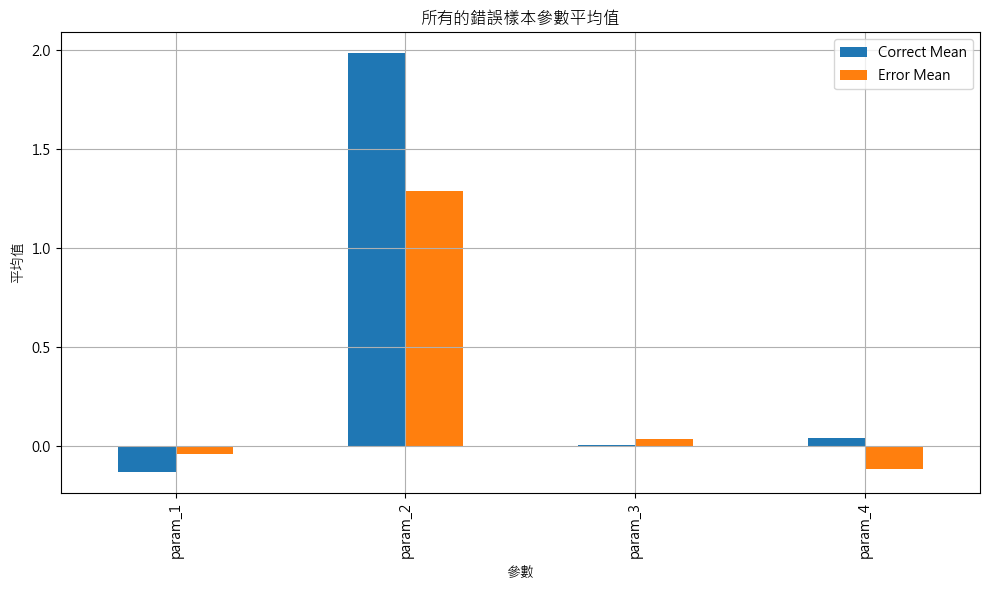

In [24]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('所有的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\error_analysis_v2.png')
plt.show()

## Sine / Cosine 錯誤分析

In [25]:
import numpy as np

In [26]:
cosine_to_sine_index = X_test.index[cosine_to_sine]
sine_to_cosine_index = X_test.index[sine_to_cosine]
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') &
                                      (error_metadata['predicted_label']=='sine')]
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') &
                                      (error_metadata['predicted_label']=='cosine')]

In [27]:
print("----以下是 Sine / Cosine 錯誤分析的結果----")
print("Noise sigma:")
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
print(f"Cosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")

----以下是 Sine / Cosine 錯誤分析的結果----
Noise sigma:
Sine被誤判成Cosine: 8
Cosine被誤判成Sine: 14


In [28]:
# 顯示 Noise 統計
print(f"Sine → Cosine:\n{sine_cosine_metadata['noise_sigma'].describe()}\n")
print(f"Cosine → Sine:\n{cosine_sine_metadata['noise_sigma'].describe()}\n")

Sine → Cosine:
count    8.000000
mean     0.032773
std      0.017086
min      0.014315
25%      0.019321
50%      0.032088
75%      0.039131
max      0.066177
Name: noise_sigma, dtype: float64

Cosine → Sine:
count    14.000000
mean      0.030532
std       0.016971
min       0.004325
25%       0.016615
50%       0.032323
75%       0.041457
max       0.065468
Name: noise_sigma, dtype: float64



In [29]:
bins = [0, 0.05, 0.10, 0.15, 0.20, np.inf]      # 將 noise_sigma 分成5個區間
labels = ['0.00 ~ 0.05',
          '0.05 ~ 0.10',
          '0.10 ~ 0.15',
          '0.15 ~ 0.20',
          '0.20+']
test_df['noise_range'] = pd.cut(test_df['noise_sigma'], bins=bins, labels=labels, include_lowest=True)
test_df['error'] = (test_df['label'] != test_df['predicted_label'])     # 判斷是否預測錯誤

In [30]:
# 計算每個 Noise 區間的錯誤率
noise_analysis = test_df.groupby('noise_range', observed=False).agg(total_samples=('error', 'count'),
                                                                    error_count=('error', 'sum'),
                                                                    error_rate=('error', 'mean'))

In [31]:
print(f"錯誤率分析:\n{noise_analysis.to_string(formatters={'error_rate': '{:.2%}'.format})}")

錯誤率分析:
             total_samples  error_count error_rate
noise_range                                       
0.00 ~ 0.05            135           24     17.78%
0.05 ~ 0.10             59            3      5.08%
0.10 ~ 0.15              6            1     16.67%
0.15 ~ 0.20              0            0        NaN
0.20+                    0            0        NaN


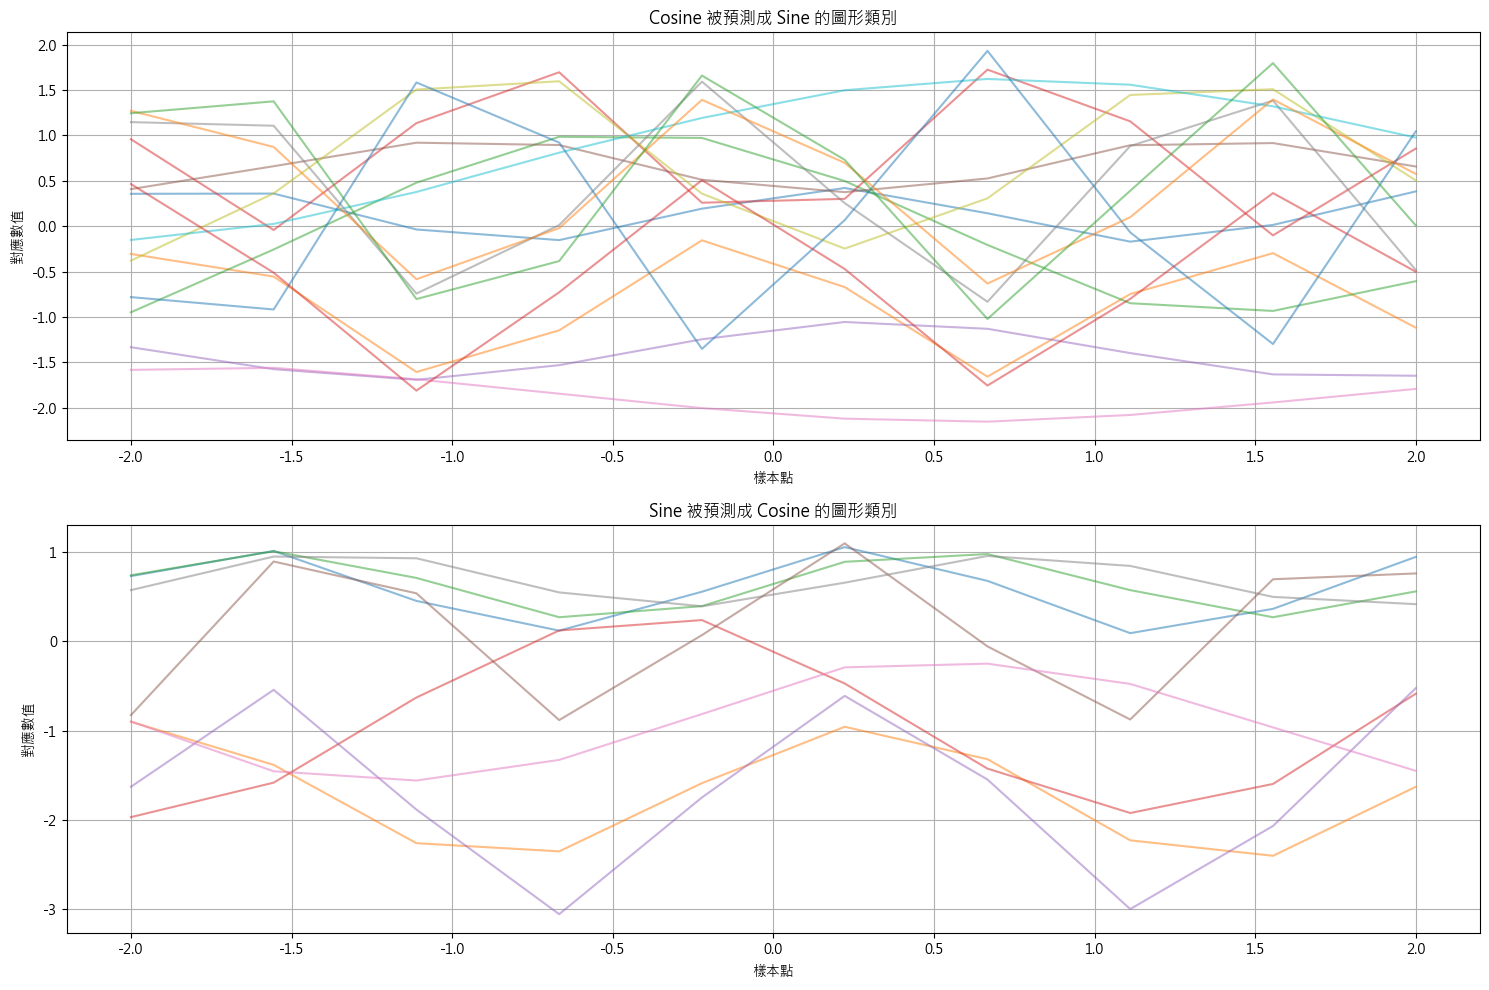

In [32]:
# 繪製圖表
xx = np.linspace(-2, 2, 10)            # Sample Points
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(2, 1, 1)
for index in cosine_to_sine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Cosine 被預測成 Sine 的圖形類別")
ax.grid()

ax = fig.add_subplot(2, 1, 2)
for index in sine_to_cosine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Sine 被預測成 Cosine 的圖形類別")
ax.grid()

plt.tight_layout()
plt.show()

### 參數分析

In [33]:
print("參數分析:")
print(f"樣本數: {len(test_df)}")
print(f"預測錯誤: {test_df['error'].sum()}")

參數分析:
樣本數: 200
預測錯誤: 28


In [34]:
sine_cosine_parameter_summary = []

In [35]:
for parameter in parameters:
    correct_data = test_df[test_df['error'] == False][parameter]
    error_data = test_df[test_df['error'] == True][parameter]
    sine_cosine_parameter_summary.append({'Parameter': parameter,
                                          'Correct Mean': correct_data.mean(),
                                          'Correct Median': correct_data.median(),
                                          'Error Mean': error_data.mean(),
                                          'Error Median': error_data.median(),
                                          'Mean Difference': (error_data.mean() - correct_data.mean())})
sine_cosine_para_sum_df = pd.DataFrame(sine_cosine_parameter_summary)

In [36]:
print("正確 vs 錯誤樣本參數比較:")
print(sine_cosine_para_sum_df.to_string(index=False, 
                                        formatters={'Correct Mean': '{:.3f}'.format,
                                                    'Correct Median': '{:.3f}'.format,
                                                    'Error Mean': '{:.3f}'.format,
                                                    'Error Median': '{:.3f}'.format,
                                                    'Mean Difference': '{:.3f}'.format}))

正確 vs 錯誤樣本參數比較:
Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1        0.036          0.300      0.224        0.344           0.188
  param_2        2.576          2.543      2.549        2.792          -0.027
  param_3       -0.006          0.007      0.005       -0.008           0.011
  param_4        0.097          0.103     -0.276        0.037          -0.373


In [37]:
# 分析每個參數的數值區間
print("各參數區間的錯誤率: ")
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_df[f'{parameter}_range'] = pd.qcut(test_df[parameter], q=4, duplicates='drop')
    analysis = test_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

各參數區間的錯誤率: 
                               total_samples  error_count error_rate
param_1_range                                                       
(-1.9909999999999999, -0.948]             50            5     10.00%
(-0.948, 0.3]                             54            9     16.67%
(0.3, 1.045]                              46            7     15.22%
(1.045, 1.936]                            50            7     14.00%


                             total_samples  error_count error_rate
param_2_range                                                     
(0.9999999999999999, 1.812]             50           10     20.00%
(1.812, 2.562]                          50            2      4.00%
(2.562, 3.408]                          50            7     14.00%
(3.408, 3.996]                          50            9     18.00%


                   total_samples  error_count error_rate
param_3_range                                           
(-0.784, -0.406]              50           12     24.0

In [38]:
# 儲存參數統計比較
para_sum_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\parameter_analysis_v2.html')

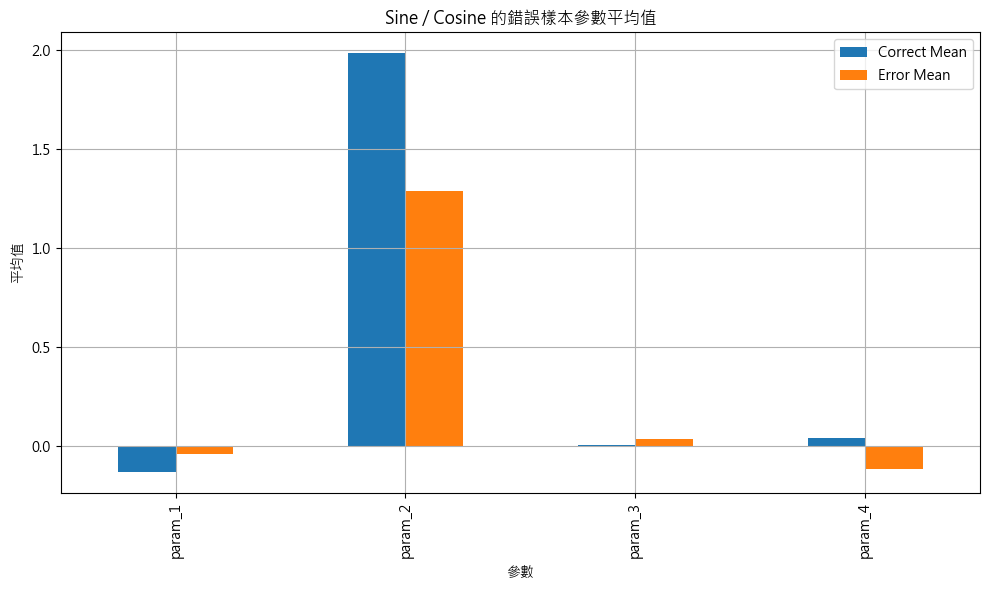

In [39]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('Sine / Cosine 的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\sine_cosine_error_analysis_v2.png')
plt.show()